In [1]:
#| default_exp models.ms_var

In [2]:
#| export

# from nbdev.showdoc import *
from __future__ import annotations
from typing import List, Dict, Optional, Callable, Tuple, Any, Union
import numpy as np
import pandas as pd
import copy
from peshbeen.transformations import (box_cox_transform, back_box_cox_transform,
                                      rolling_quantile,
                        expanding_mean, expanding_std, expanding_quantile)
from peshbeen.helpers import seasonal_diff, undiff_ts, invert_seasonal_diff
from peshbeen.model_selection import SplitTimeSeries
from peshbeen.statstools import lr_trend_model, forecast_trend
# dot not show warnings
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import multivariate_normal
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.special import logsumexp
from scipy.stats import t
from sklearn.compose import ColumnTransformer


class ms_var:

    def __init__(
        self,
        n_components: int,
        target_cols: List[str],
        lags: Dict[str, Union[int, List[int]]],
        lag_transform: Optional[Dict[str, list]] = None,
        difference: Optional[Dict[str, int]] = None,
        seasonal_diff: Optional[Dict[str, int]] = None,
        trend: Optional[Dict[str, str]] = None,
        pol_degree: Optional[Union[int, Dict[str, int]]] = 1,
        ets_params: Optional[Dict[str, tuple]] = None,
        change_points: Optional[Dict[str, List[int]]] = None,
        box_cox: Optional[Dict[str, Union[bool, float, int]]] = None,
        box_cox_biasadj: Optional[Dict[str, bool]] = None,
        add_constant: bool = True,
        cat_variables: Optional[List[str]] = None,
        categorical_encoder: Optional[Union[Dict[str, Any], Any]] = None,
        method: str = "posterior",
        covariance_type: str = "full",
        switching_cov: bool = True,
        startprob_prior: float = 1e3,
        transmat_prior: float = 1e5,
        n_iter: int = 100,
        tol: float = 1e-3,
        coefficients: Optional[List[np.ndarray]] = None,
        init_state: Optional[np.ndarray] = None,
        trans_matrix: Optional[np.ndarray] = None,
        random_state: Optional[int] = None,
        verbose: bool = False
    ) -> None:

        """
        Initialize the Markov-Switching Vector Autoregression (MS-VAR) model with specified parameters and preprocessing options.

        Parameters
        ----------
        n_components : int
            Number of hidden states (regimes) in the model.
        target_cols : List[str]
            List of column names corresponding to the target variables in the input DataFrame.
        lags : Dict[str, Union[int, List[int]]]
            Dictionary specifying the lags to include for each target variable. The keys are target column names, and the values can be either an integer (which expands to a list of lags from 1 to that integer) or a list of specific lag integers.
        lag_transform : Optional[Dict[str, list]], default=None
            Dictionary specifying lag-transform functions to apply to each target variable. The keys are target column names, and the values are lists of transformation functions (e.g., rolling mean, expanding std).
        difference : Optional[Dict[str, int]], default=None
            Dictionary specifying the order of ordinary differencing to apply to each target variable. The keys are target column names, and the values are integers indicating the number of differences (e.g., 1 for first difference).
        seasonal_diff : Optional[Dict[str, int]], default=None
            Dictionary specifying the order of seasonal differencing to apply to each target variable. The keys are target column names, and the values are integers indicating the seasonal period (e.g., 12 for monthly data with yearly seasonality).
        trend : Optional[Dict[str, str]], default=None
            Dictionary specifying the trend component to include for each target variable. The keys are target column names, and the values are strings indicating the type of trend (e.g., 'linear', 'ets').
        pol_degree : Optional[Union[int, Dict[str, int]]], default=1
            Degree of polynomial for trend component. Can be a single integer applied to all targets or a dictionary keyed by target column name.
        ets_params : Optional[Dict[str, tuple]], default=None
            Dictionary specifying ETS model parameters for trend removal. The keys are target column names, and the values are tuples containing the arguments for ExponentialSmoothing (first element) and its fit method (second element).
        change_points : Optional[Dict[str, List[int]]], default=None
            Dictionary specifying change points for piecewise linear trend removal. The keys are target column names, and the values are lists of integer indices where the trend slope changes.
        box_cox : Optional[Dict[str, Union[bool, float, int]]], default=None
            Dictionary specifying whether to apply Box-Cox transformation to each target variable. Values can be a boolean (True to apply, False to skip), a float (lambda parameter for Box-Cox transformation), or an integer (seasonal period for seasonal Box-Cox transformation). If True, lambda will be estimated from the data.
        box_cox_biasadj : Optional[Dict[str, bool]], default=None
            Dictionary specifying whether to apply bias adjustment when inverting the Box-Cox transformation for each target variable. The keys are target column names, and the values are booleans indicating whether to apply bias adjustment.
        add_constant : bool, default=True
            If True, a constant column will be added to the regressor matrix for each state.
        cat_variables : Optional[List[str]], optional
            List of categorical feature column names to encode. These will be shared across all target variables.
        categorical_encoder : Optional[Union[Dict[str, Any], Any]], optional
            A categorical encoder instance, or a single-entry dictionary mapping the target column to the encoder when the encoder requires access to the target variable during fitting (e.g. {target_col: MeanEncoder()}). If encoder requiring target access is provided directly without the dict format, first target column in target_cols will be used for fitting the encoder. For encoders that do not require target access, pass the encoder instance directly (e.g. OneHotEncoder()).
        method : str, default='posterior'
            Method for state assignment during the E-step. Options are 'posterior' for soft assignments based on posterior probabilities or 'viterbi' for hard assignments using the Viterbi algorithm.
        covariance_type : str, default='full'
            Structure of the emission covariance matrices. Options are 'full' for full covariance matrices or 'diag' for diagonal covariance matrices.
        switching_cov : bool, default=True
            If True, allow the covariance matrices to switch between states. If False, a single covariance matrix will be shared across all states.
        startprob_prior : float, default=1e3
            Concentration parameter for the Dirichlet prior on the initial state distribution. Higher values lead to more uniform priors.
        transmat_prior : float, default=1e5
            Concentration parameter for the Dirichlet prior on the transition matrix rows. Higher values lead to more uniform priors.
        n_iter : int, default=100
            Maximum number of EM iterations to perform during training.
        tol : float, default=1e-3
            Convergence threshold for EM. Training will stop if the change in log-likelihood between iterations is less than this value.
        coefficients : Optional[List[np.ndarray]], default=None
            Optional initial state-wise VAR coefficient matrices. If None, they will be initialized using ordinary least squares on the entire dataset.
        init_state : Optional[np.ndarray], default=None
            Optional initial state probability vector. If None, it will be initialized from a Dirichlet distribution with concentration parameter `startprob_prior`.
        trans_matrix : Optional[np.ndarray], default=None
            Optional initial transition matrix. If None, it will be initialized from a Dirichlet distribution with concentration parameter `transmat_prior`.
        random_state : Optional[int], default=None
            Random seed for reproducibility of the initial state distribution and transition matrix.
        verbose : bool, default=False
            If True, print log-likelihood at each EM iteration and convergence message.
        
        Returns
        -------
        None
        """
        self.N = n_components
        self.target_cols = target_cols
        self.cat_variables = cat_variables
        if categorical_encoder is not None:
            if isinstance(categorical_encoder, dict):
                if len(categorical_encoder) != 1:
                    raise ValueError("If categorical_encoder is a dict, it must contain exactly one entry mapping a target column to the encoder instance.")
                encoder_target_col, encoder = next(iter(categorical_encoder.items())) # get the single key-value pair from the dict
                if encoder_target_col not in self.target_cols:
                    raise ValueError("The single key in categorical_encoder must be one of target_cols.")
                self.cat_encoder_key = encoder_target_col
                self.cat_encoder = encoder
            else:
                self.cat_encoder = categorical_encoder
                self.cat_encoder_key = self.target_cols[0] # just get one of the target columns since we are not using the encoder in a target-specific way, but we will check for target access requirement later when we fit the encoder

        else:
            # self.cat_encoder_key = None
            self.cat_encoder = None

        self.cons = add_constant
        self.method = method
        self.iter = n_iter
        self.tol = tol
        self.verb = verbose
        self.cvr = covariance_type
        self.switching_cov = switching_cov
        self.coeffs = coefficients
        self.cps = change_points

        # ── lags ──────────────────────────────────────────────────────────────
        if not isinstance(lags, dict):
            raise TypeError("lags must be a dict keyed by target column name.")
        self.lags = {
            col: (v if isinstance(v, list) else list(range(1, v + 1)))
            for col, v in lags.items()
        }

        # ── lag_transform ─────────────────────────────────────────────────────
        self.lag_transform = lag_transform

        # ── differencing ──────────────────────────────────────────────────────
        self.diffs = {col: None for col in target_cols}
        if difference is not None:
            if not isinstance(difference, dict):
                raise TypeError("difference must be a dict keyed by target column name.")
            self.diffs.update(difference)

        # ── seasonal differencing ─────────────────────────────────────────────
        self.season_diffs = {col: None for col in target_cols}
        if seasonal_diff is not None:
            if not isinstance(seasonal_diff, dict):
                raise TypeError("seasonal_diff must be a dict keyed by target column name.")
            self.season_diffs.update(seasonal_diff)

        # ── trend ─────────────────────────────────────────────────────────────
        self.trend = trend
        if trend is not None and not isinstance(trend, dict):
            raise TypeError("trend must be a dict keyed by target column name.")
        
        if self.trend is not None and 'ets' in trend.values():
            if ets_params is None:
                # assign default ETS parameters if not provided
                self.ets_params = {col: ({}, {}) for col, type in trend.items() if type == 'ets'}
            else:
                if not isinstance(ets_params, dict):
                    raise TypeError("ets_params must be a dict keyed by target column name.")
                self.ets_params = ets_params
                for col in target_cols:
                    if trend.get(col) == 'ets' and col not in self.ets_params:
                        self.ets_params[col] = ({}, {})  # default parameters for any ETS target not specified

        # ── polynomial degree ─────────────────────────────────────────────────
        if isinstance(pol_degree, int):
            self.pol = {col: pol_degree for col in target_cols}
        elif isinstance(pol_degree, dict):
            self.pol = {col: pol_degree.get(col, 1) for col in target_cols}
        else:
            raise ValueError("pol_degree must be an int or a dict.")

        # ── box-cox ───────────────────────────────────────────────────────────
        # initialise biasadj regardless of box_cox
        if isinstance(box_cox_biasadj, bool):
            self.biasadj = {col: box_cox_biasadj for col in target_cols}
        elif isinstance(box_cox_biasadj, dict):
            self.biasadj = {col: box_cox_biasadj.get(col, False) for col in target_cols}
        else:
            self.biasadj = {col: False for col in target_cols}

        if box_cox is not None:
            self.box_cox: Dict[str, bool] = {}
            self.lamdas: Dict[str, Optional[float]] = {col: None for col in target_cols}
            
            if isinstance(box_cox, bool):          # ← bool before (float, int)
                self.box_cox = {col: box_cox for col in target_cols}
            elif isinstance(box_cox, (float, int)):
                self.box_cox = {col: True for col in target_cols}
                self.lamdas = {col: box_cox for col in target_cols}
            elif isinstance(box_cox, dict):
                for col, val in box_cox.items():
                    if isinstance(val, bool):          # ← bool before (float, int)
                        self.box_cox[col] = val
                        self.lamdas[col] = None
                    elif isinstance(val, (float, int)):
                        self.box_cox[col] = True
                        self.lamdas[col] = val
                    else:
                        raise ValueError(
                            f"Invalid value for box_cox['{col}']: must be bool or float."
                        )
            else:
                raise TypeError(
                    "box_cox must be a bool, float, or dict keyed by target column name."
                )
            
        else:
            self.box_cox = box_cox
            
        # ── HMM initialisation ────────────────────────────────────────────────
        self.rng = np.random.default_rng(random_state)

        if init_state is None:
            self.pi = self.rng.dirichlet(np.repeat(startprob_prior, self.N))
        else:
            self.pi = np.array(init_state)

        if trans_matrix is None:
            self.A = self.rng.dirichlet(np.repeat(transmat_prior, self.N), size=self.N)
        else:
            self.A = np.array(trans_matrix)

    # ─────────────────────────────────────────────────────────────────────────
    # DATA PREPARATION
    # ─────────────────────────────────────────────────────────────────────────

    def data_prep(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Apply all preprocessing transformations to df and return the cleaned DataFrame.
        Also builds self.X, self.y, self.T and initialises coefficients if needed.
        """
        dfc = df.copy()

        # ── categorical encoding ──────────────────────────────────────────────
        if self.cat_variables is not None:
            dfc = self.create_encoded_features(dfc)

        if not all(col in dfc.columns for col in self.target_cols):
            return dfc.dropna()

        self.orig_target = dfc[self.target_cols].values # store for generating in sample residuals later

        # ── Box-Cox ───────────────────────────────────────────────────────────
        if self.box_cox is not None:
            self.is_zeros: Dict[str, bool] = {} # track if shift was applied for each target
            self.trans_data: Dict[str, np.ndarray] = {} # store transformed data for in-sample residual calculations
            for col in self.target_cols:
                if self.box_cox.get(col, False): # only apply if box_cox is True for this target
                    self.is_zeros[col] = (dfc[col] < 1).any()
                    trans_data, self.lamdas[col] = box_cox_transform(
                        x=dfc[col], shift=self.is_zeros[col], box_cox_lmda=self.lamdas[col]
                    ) # returns transformed data and lambda. If lambda is not provided, it is estimated from the data.
                    dfc[col] = trans_data
                    self.trans_data[col] = trans_data

        # ── Trend removal ─────────────────────────────────────────────────────
        if self.trend is not None:
            self.len = len(df)
            self.orig_targets: Dict[str, pd.Series] = {}
            self.trend_models: Dict[str, Any] = {}

            for col, ttype in self.trend.items():
                self.orig_targets[col] = dfc[col].copy()

                if ttype == "linear":
                    bps = self.cps.get(col) if self.cps else None
                    if bps:
                        trend_vals, model_fit, _ = lr_trend_model(
                            self.orig_targets[col], degree=self.pol[col],
                            breakpoints=bps, type='piecewise'
                        )
                    else:
                        trend_vals, model_fit, _ = lr_trend_model(
                            self.orig_targets[col], degree=self.pol[col]
                        )
                    dfc[col] = dfc[col] - trend_vals
                    self.trend_models[col] = model_fit

                elif ttype == "ets":
                    ep = self.ets_params[col]
                    model_fit = ExponentialSmoothing(
                        self.orig_targets[col], **ep[0]
                    ).fit(**ep[1])
                    dfc[col] = dfc[col] - model_fit.fittedvalues.values
                    self.trend_models[col] = model_fit

                else:
                    raise ValueError(
                        f"Unknown trend type '{ttype}' for '{col}'. Use 'linear' or 'ets'."
                    )

        # ── Ordinary differencing ─────────────────────────────────────────────
        self.origs: Dict[str, list] = {}
        for col, d in self.diffs.items():
            if d is not None:
                self.origs[col] = dfc[col].tolist()
                dfc[col] = np.diff(dfc[col], n=d, prepend=np.repeat(np.nan, d))

        # ── Seasonal differencing ─────────────────────────────────────────────
        self.orig_ds: Dict[str, list] = {}
        for col, s in self.season_diffs.items():
            if s is not None:
                self.orig_ds[col] = dfc[col].tolist()
                dfc[col] = seasonal_diff(dfc[col], s)

        # ── Lag features ──────────────────────────────────────────────────────
        for col, lags in self.lags.items():
            for lag in lags:
                dfc[f"{col}_lag_{lag}"] = dfc[col].shift(lag)

        # ── Lag transforms ────────────────────────────────────────────────────
        if self.lag_transform is not None:
            for idx, (col, funcs) in enumerate(self.lag_transform.items()):
                for func in funcs:
                    if isinstance(func, (expanding_std, expanding_mean)):
                        dfc[f"trg{idx}_{func.__class__.__name__}_shift_{func.shift}"] = func(dfc[col])
                    elif isinstance(func, expanding_quantile):
                        dfc[f"trg{idx}_{func.__class__.__name__}_shift_{func.shift}_q{func.quantile}"] = func(dfc[col])
                    elif isinstance(func, rolling_quantile):
                        dfc[f"trg{idx}_{func.__class__.__name__}_{func.window_size}_shift_{func.shift}_q{func.quantile}"] = func(dfc[col])
                    else:
                        dfc[f"trg{idx}_{func.__class__.__name__}_{func.window_size}_shift_{func.shift}"] = func(dfc[col])

        # ── Build X / y arrays ────────────────────────────────────────────────
        df_clean = dfc.dropna()
        X = df_clean.drop(columns=self.target_cols)
        if self.cons:
            X.insert(0, 'const', 1)
        self.col_names = X.columns.tolist() if hasattr(X, 'columns') else [f"x{i}" for i in range(X.shape[1])]
        self.X = np.array(X)
        self.y = np.array(df_clean[self.target_cols])
        self.T = len(self.y)

        # ── Initialise coefficients if not provided ───────────────────────────
        if self.coeffs is None:
            coeffs, covs = [], []
            for _ in range(self.N):
                beta = np.linalg.lstsq(self.X, self.y, rcond=None)[0]
                coeffs.append(beta)
                resid = self.y - self.X @ beta
                eff_df = max(len(resid) - self.X.shape[1], 1)
                covs.append((resid.T @ resid) / eff_df)
            self.coeffs = np.stack(coeffs, axis=0)
            self.covs = np.array(covs)

        return df_clean

    # ─────────────────────────────────────────────────────────────────────────
    # EMISSIONS
    # ─────────────────────────────────────────────────────────────────────────

    def _log_emissions(self):
        N, T = self.N, self.T
        logB = np.empty((N, T))
        self.fitted = np.empty((N, T, self.y.shape[1]))
        for s in range(N):
            mus = self.X @ self.coeffs[s]
            self.fitted[s, :, :] = mus
            for t in range(T):
                logB[s, t] = multivariate_normal(mean=mus[t], cov=self.covs[s]).logpdf(self.y[t])
        return logB

    # ─────────────────────────────────────────────────────────────────────────
    # E-STEP
    # ─────────────────────────────────────────────────────────────────────────

    def _e_step_log(self):
        N, T = self.N, self.T
        logA  = np.log(self.A + 1e-300)
        logpi = np.log(self.pi + 1e-300)
        logB  = self._log_emissions()

        # Forward
        log_alpha = np.empty((N, T))
        log_alpha[:, 0] = logpi + logB[:, 0]
        for t in range(1, T):
            log_alpha[:, t] = logB[:, t] + logsumexp(log_alpha[:, t-1][:, None] + logA, axis=0)

        loglik = logsumexp(log_alpha[:, -1])

        # Backward
        log_beta = np.full((N, T), 0.0)
        for t in range(T-2, -1, -1):
            log_beta[:, t] = logsumexp(logA + (logB[:, t+1] + log_beta[:, t+1])[None, :], axis=1)

        # Gamma
        log_gamma = log_alpha + log_beta - loglik
        log_gamma -= logsumexp(log_gamma, axis=0)
        gamma = np.exp(log_gamma)

        # Xi
        log_xi = np.empty((N, N, T-1))
        for t in range(T-1):
            tmp = log_alpha[:, t][:, None] + logA + (logB[:, t+1] + log_beta[:, t+1])[None, :]
            tmp -= logsumexp(tmp)
            log_xi[:, :, t] = tmp
        xi = np.exp(log_xi)

        assert np.allclose(gamma.sum(axis=0), 1.0, atol=1e-8)
        assert np.allclose(xi.sum(axis=(0, 1)), 1.0, atol=1e-8)

        self.log_forward  = log_alpha
        self.log_backward = log_beta
        self.posterior    = gamma
        self.loglik       = loglik
        return loglik, gamma, xi

    # ─────────────────────────────────────────────────────────────────────────
    # M-STEP
    # ─────────────────────────────────────────────────────────────────────────

    def _m_step(self, gamma, xi):
        numer = xi.sum(axis=2)
        denom = gamma[:, :-1].sum(axis=1, keepdims=True)
        A = numer / (denom + 1e-12)
        A = np.maximum(A, 1e-12)
        A /= A.sum(axis=1, keepdims=True)
        self.A = A
        self.pi = gamma[:, 0] / gamma[:, 0].sum()
        self.compute_coeffs()

    def EM(self):
        loglik, gamma, xi = self._e_step_log()
        self._m_step(gamma, xi)
        self.LL = loglik

    # ─────────────────────────────────────────────────────────────────────────
    # COEFFICIENT UPDATE
    # ─────────────────────────────────────────────────────────────────────────

    def compute_coeffs(self, ridge: float = 1e-5, var_floor: float = 1e-5, w_floor: float = 1e-6):
        """Update regression coefficients and covariance matrices for each state."""

        # Align X / y / posterior lengths
        if self.posterior.shape[1] < self.X.shape[0]:
            self.X = self.X[:self.posterior.shape[1]]
            self.y = self.y[:self.posterior.shape[1]]
        if self.posterior.shape[1] > self.X.shape[0]:
            self.posterior = self.posterior[:, -self.X.shape[0]:]

        X, y = self.X, self.y
        coeffs, covs = [], []

        for s in range(self.N):
            w = self.posterior[s] + w_floor
            w /= w.sum()
            sw = np.sqrt(w)
            self.sw = sw
            Xw = X * sw[:, None]
            yw = y * sw[:, None]
            XtX = Xw.T @ Xw + ridge * np.eye(X.shape[1])
            Xty = Xw.T @ yw
            beta_s = np.linalg.lstsq(XtX, Xty, rcond=None)[0]
            coeffs.append(beta_s)

            resid = y - X @ beta_s
            eff_df = max(np.sum(w) - X.shape[1], 1)
            cov_i = (w[:, None] * resid).T @ resid / eff_df

            # Regularise covariance via eigenvalue clipping
            eigvals, eigvecs = np.linalg.eigh(cov_i)
            eigvals = np.clip(eigvals, var_floor, None)
            cov_i = eigvecs @ np.diag(eigvals) @ eigvecs.T
            covs.append(cov_i)

        self.coeffs = np.stack(coeffs)

        if not self.switching_cov:
            mean_cov = sum(covs) / self.N
            if self.cvr == "diag":
                mean_cov = np.diag(np.diag(mean_cov))
            self.covs = [mean_cov for _ in range(self.N)]
        else:
            if self.cvr == "full":
                self.covs = covs
            elif self.cvr == "diag":
                self.covs = [np.diag(np.diag(c)) for c in covs]

    # ─────────────────────────────────────────────────────────────────────────
    # ENCODE CATEGORICAL FEATURES
    # ─────────────────────────────────────────────────────────────────────────

    def create_encoded_features(self,
                    df: pd.DataFrame
                    ) -> pd.DataFrame:
        
        ## make sure categorical variables are treated as category dtype for encoding
        for col in self.cat_variables:
            df[col] = df[col].astype('category')
        ## if fit has been called but forecat has not been called yet, we can fit the encoder on the training data and store it for use during forecasting

        if self.cat_encoder is not None:
            # if self.target_col in df.columns and not hasattr(self, "model_fit"):
            if all(col in df.columns for col in self.target_cols): # if we have target values, we are in the fit stage and can fit the encoder on the training data (if not already fitted) and then transform the data for model fitting
                num_cols = [c for c in df.columns if c not in self.cat_variables + self.target_cols]

                # pass_cols = self.cat_variables + num_cols
                self.preprocess = ColumnTransformer(
                    transformers=[("cat", self.cat_encoder, self.cat_variables), ("num", "passthrough", num_cols)],
                    remainder="drop",
                    verbose_feature_names_out=False
                ).set_output(transform="pandas")

                X_train = self.preprocess.fit_transform(df.drop(columns=self.target_cols), y=df[self.cat_encoder_key])
                return pd.concat([df[self.target_cols], X_train], axis=1)
            
            else: # if we do not have target values, we are in the forecast stage and can just transform the data using the already fitted encoder
                return self.preprocess.transform(df)
        else:
            raise ValueError("cat_variables is specified but cat_encoder is None. Please provide a categorical encoder instance to encode the categorical variables.")
            
    # ─────────────────────────────────────────────────────────────────────────
    # FIT (EM training)
    # ─────────────────────────────────────────────────────────────────────────

    def fit(self,
               df: pd.DataFrame
               ) -> float:
        
        """
        Fit the model using EM iterations until convergence on training data.

        Parameters
        ----------
        df : pd.DataFrame
            Training DataFrame containing all target and feature columns. Must include the columns specified in `target_cols` and any columns needed as regressors (e.g., categorical variables).
        
        Returns
        -------
        float
            Final log-likelihood after the additional EM iterations.
        """

        self.data_prep(df)

        prev_ll = -np.inf
        self.log_likelihoods = []

        for it in range(self.iter):
            self.EM()
            if self.verb:
                print(f"Iter {it}: loglik={self.LL:.4f}")
            if it > 10 and abs(self.LL - prev_ll) < self.tol:
                if self.verb:
                    print("Converged.")
                break
            self.log_likelihoods.append(self.LL)
            prev_ll = self.LL


        self.is_fitted = True
        return self.LL
    
    def predict_in_sample(self) -> np.ndarray:
        """
        Generate in-sample predictions and residuals for the training data. This can be useful for diagnostic purposes, such as checking for patterns in the residuals or calculating in-sample performance metrics.

        Returns
        -------
        np.ndarray
            In-sample fitted values and residuals for the training data.
        """

        # state_fitted shape: (n_states, n_obs, n_targets)
        fit_len = self.X.shape[0]
        state_fitted = np.einsum('tp,spk->stk', self.X, self.coeffs) # shape: (n_states, n_obs, n_targets)
        self.weighted_fitted = (state_fitted * self.posterior[:, :, None]).sum(axis=0) # shape: (n_obs, n_targets)
        self.in_samp_resids = {col: self.y[:, i] - self.weighted_fitted[:, i] for i, col in enumerate(self.target_cols)} # store in-sample residuals for each target variable in a dict keyed by target column name
        
        self.fitted_values = {col: self.orig_target[-fit_len:, i] + self.in_samp_resids[col] for i, col in enumerate(self.target_cols)} # start with original target values and add residuals to get fitted values in original scale (after all transformations are inverted in the correct order below)
        if self.box_cox is not None:
            for i, col in enumerate(self.target_cols):
                if self.box_cox.get(col, False):
                    bc_fitted = self.trans_data[col][-fit_len:] + self.in_samp_resids[col]
                    self.fitted_values[col] = back_box_cox_transform(
                        y_pred=bc_fitted, lmda=self.lamdas[col],
                        shift=self.is_zeros.get(col, False), box_cox_biasadj=self.biasadj[col]
                    )
                    self.in_samp_resids[col] = self.orig_target[-fit_len:, i] - self.fitted_values[col]

    # ─────────────────────────────────────────────────────────────────────────
    # FIT (refit on new data)
    # ─────────────────────────────────────────────────────────────────────────

    # def fit(self,
    #         df: pd.DataFrame,
    #         n_iter: int = 1
    #         ) -> float:
        
    #     """
    #     Refit the model on new data using additional EM iterations.

    #     Parameters
    #     ----------
    #     df : pd.DataFrame
    #         New training DataFrame containing all target and feature columns. Must include the columns specified in `target_cols` and any columns needed as regressors (e.g., categorical variables).
    #     n_iter : int, default=1
    #         Number of additional EM iterations to run after refitting on the new data. Must be at least 1.
        
    #     Returns
    #     -------
    #     float
    #         Final log-likelihood after the additional EM iterations.
    #     """

    #     if n_iter < 1:
    #         raise ValueError("n_iter must be at least 1.")

    #     self.data_prep(df)

    #     if n_iter > 1:
    #         prev_ll = self.LL
    #         for it in range(n_iter):
    #             self.EM()
    #             if self.verb:
    #                 print(f"Iter {it}: loglik={self.LL:.4f}")
    #             if abs(self.LL - prev_ll) < self.tol:
    #                 break
    #             prev_ll = self.LL
    #     else:
    #         self.EM()

    #     return self.LL

    # ─────────────────────────────────────────────────────────────────────────
    # STATE INFERENCE
    # ─────────────────────────────────────────────────────────────────────────

    # def predict_states(self) -> np.ndarray:
    #     """Return the most likely state at each time step (hard assignment)."""
    #     return np.argmax(self.posterior, axis=0)

    # def predict_proba(self) -> np.ndarray:
    #     """Return the full posterior probability matrix (N x T)."""
    #     return self.posterior
    
    def predict_states(self) -> np.ndarray:
        """Return the most likely state at each time step (hard assignment)."""
        # the length of the posterior may be shorter than the original data due to lag features, so we add NaNs for the initial periods where posterior is not available
        if self.posterior.shape[1] < self.orig_target.shape[0] and not np.isnan(self.posterior).any(): # and if predict proba has not been called yet to add the NaN padding, we add it here so that the posterior and state predictions are aligned with the original data length
            padding = np.full((self.N, self.orig_target.shape[0] - self.posterior.shape[1]), np.nan)
            self.posterior = np.hstack([padding, self.posterior])
        return np.argmax(self.posterior, axis=0)

    def predict_proba(self) -> np.ndarray:
        """Return the full posterior probability matrix (N x T)."""
        # posterior is N x T matrix of state probabilities at each time step but should be same length as original data, so we add NaNs for the initial periods where posterior is not available due to lag features
        if self.posterior.shape[1] < self.orig_target.shape[0] and not np.isnan(self.posterior).any():
            padding = np.full((self.N, self.orig_target.shape[0] - self.posterior.shape[1]), np.nan)
            self.posterior = np.hstack([padding, self.posterior])
        return self.posterior

    # ─────────────────────────────────────────────────────────────────────────
    # INFORMATION CRITERIA
    # ─────────────────────────────────────────────────────────────────────────

    def _ic_base(self):
        d = self.y.shape[1]
        r = self.X.shape[1]
        per_regime = r * d + d * (d + 1) / 2
        k = self.N * per_regime + self.N * (self.N - 1) + (self.N - 1)
        n = self.T
        return k, n

    @property
    def aic(self) -> float:
        k, n = self._ic_base()
        return 2 * k - 2 * self.LL

    @property
    def aicc(self) -> float:
        k, n = self._ic_base()
        correction = (2 * k * (k + 1)) / (n - k - 1) if n - k - 1 > 0 else 0
        return self.aic + correction

    @property
    def bic(self) -> float:
        k, n = self._ic_base()
        return -2 * self.LL + k * np.log(n)

    @property
    def hqc(self) -> float:
        k, n = self._ic_base()
        return -2 * self.LL + 2 * k * np.log(np.log(n))

    def copy(self):
        return copy.deepcopy(self)

    # ─────────────────────────────────────────────────────────────────────────
    # FORECAST
    # ─────────────────────────────────────────────────────────────────────────

    def forecast(
        self,
        H: int,
        exog: Optional[pd.DataFrame] = None
    ) -> Dict[str, np.ndarray]:
        
        """
        Generate forecasts for H future time steps using the fitted MS-VAR model.

        Parameters
        ----------
        H : int
            Forecast horizon (number of future time steps to predict).
        exog : Optional[pd.DataFrame], default=None
            Future exogenous regressors. If provided, must contain at least H rows and the same columns as the regressors used during training (excluding target columns).
        
        Returns
        -------
        Dict[str, np.ndarray]
            Forecasted values for each target variable, returned as a dictionary keyed by target column name.
        """
        # Rolling history for each target
        y_lists: Dict[str, list] = {
            col: self.y[:, i].tolist()
            for i, col in enumerate(self.target_cols)
        }

        # ── Prepare exog ──────────────────────────────────────────────────────
        if exog is not None:
            exog = self.data_prep(exog)
            exog = np.array(exog)
        
        cons = [1] if self.cons else []

        # ── Pre-compute trend forecasts ───────────────────────────────────────
        trend_forecasts: Dict[str, np.ndarray] = {}

        if self.trend is not None:
            for col, ttype in self.trend.items():
                if ttype == "linear":
                    bps = self.cps.get(col) if self.cps else None
                    trend_forecasts[col], _ = forecast_trend(
                        model=self.trend_models[col], H=H,
                        start=self.len, degree=self.pol[col], breakpoints=bps)
                elif ttype == "ets":
                    trend_forecasts[col] = np.array(self.trend_models[col].forecast(H))

        # ── Forward probabilities for H future steps ──────────────────────────
        logA = np.log(self.A + 1e-300)
        log_alpha = np.empty((self.N, H))
        log_alpha[:, 0] = logsumexp(self.log_forward[:, -1][:, None] + logA, axis=0)
        for t in range(1, H):
            log_alpha[:, t] = logsumexp(log_alpha[:, t-1][:, None] + logA, axis=0)
        log_alpha -= logsumexp(log_alpha, axis=0)
        self.forecast_forward = np.exp(log_alpha)
        self.state_forecasts = np.argmax(self.forecast_forward, axis=0)

        # ── Recursive forecast loop ───────────────────────────────────────────
        raw_forecasts: Dict[str, list] = {col: [] for col in self.target_cols}

        for t in range(H):
            # Exogenous features for step t
            exo_inp = exog[t].tolist() if exog is not None else []

            # Lag features
            inp_lag = []
            for col, lags in self.lags.items():
                inp_lag.extend([y_lists[col][-x] for x in lags])

            # Lag-transform features
            transform_lag = []
            if self.lag_transform is not None:
                for col, funcs in self.lag_transform.items():
                    series_array = np.array(y_lists[col])
                    for func in funcs:
                        transform_lag.append(func(series_array, is_forecast=True).to_numpy()[-1])

            inp = np.array(cons + exo_inp + inp_lag + transform_lag)

            # State-weighted prediction
            state_preds: Dict[str, np.ndarray] = {col: np.zeros(self.N) for col in self.target_cols}
            for j in range(self.N):
                mus = inp @ self.coeffs[j]   # shape: (n_targets,)
                for i, col in enumerate(self.target_cols):
                    state_preds[col][j] = mus[i]

            for col in self.target_cols:
                pred = np.sum(self.forecast_forward[:, t] * state_preds[col])
                raw_forecasts[col].append(pred)
                y_lists[col].append(pred)

        # ── Post-processing ───────────────────────────────────────────────────
        forecasts: Dict[str, np.ndarray] = {
            col: np.array(raw_forecasts[col]) for col in self.target_cols
        }

        # Add back removed trend
        if self.trend is not None:
            for col in self.trend:
                forecasts[col] = forecasts[col] + trend_forecasts[col]

        # Invert seasonal differencing
        for col, s in self.season_diffs.items():
            if s is not None:
                forecasts[col] = invert_seasonal_diff(self.orig_ds[col], forecasts[col], s)

        # Invert ordinary differencing
        for col, d in self.diffs.items():
            if d is not None:
                forecasts[col] = undiff_ts(self.origs[col], forecasts[col], d)

        # Non-negativity
        for col in forecasts:
            forecasts[col] = np.array([max(0, x) for x in forecasts[col]])

        # Invert Box-Cox
        if self.box_cox is not None:
            for col in self.target_cols:
                if self.box_cox.get(col, False):
                    forecasts[col] = back_box_cox_transform(
                        y_pred=forecasts[col],
                        lmda=self.lamdas[col],
                        shift=self.is_zeros.get(col, False),
                        box_cox_biasadj=self.biasadj[col]
                )

        return forecasts

    # ─────────────────────────────────────────────────────────────────────────
    # PARAMETER SUMMARY
    # ─────────────────────────────────────────────────────────────────────────

    def get_param_spec(self):
        """
        Compute and store coefficient tables, regime probabilities, transition
        matrix, covariance matrices, and fit diagnostics.
        """
        T = len(self.y)
        p = sum(self.coeffs.shape)
        df = T - p

        results = np.empty((self.y.shape[1], self.N, 4, self.coeffs.shape[1]))
        for s in range(self.N):
            xw = self.posterior[s][:, None] * self.X
            yw = self.posterior[s][:, None] * self.y
            yw_fit = self.coeffs[s, :, :].T @ xw.T
            resid = yw - yw_fit.T

            res_cov = (resid.T @ resid) / df
            cov_diag = res_cov.diagonal()
            w_d = np.diag(self.posterior[s])
            XtWX_1 = np.linalg.inv(self.X.T @ w_d @ self.X)
            var_b = cov_diag[:, None, None] * XtWX_1[None, :, :]
            se_b = np.sqrt(var_b)
            t_s = self.coeffs[s, :, :].T / np.diagonal(se_b, axis1=1, axis2=2)
            p_values = (1 - t.cdf(np.abs(t_s), df)) * 2

            for i in range(self.y.shape[1]):
                results[i, s, 0, :] = self.coeffs[s, :, i]
                results[i, s, 1, :] = np.diagonal(se_b, axis1=1, axis2=2)[i]
                results[i, s, 2, :] = t_s[i]
                results[i, s, 3, :] = p_values[i]

        arrs = np.vstack([
            np.concatenate([results[i, j, :, :].T for j in range(results.shape[1])], axis=1)
            for i in range(self.y.shape[1])
        ])
        multi_vr = (
            pd.DataFrame(arrs, index=self.col_names * self.y.shape[1])
            .reset_index()
            .rename(columns={"index": "variable"})
        )
        grp = [
            f"Results for equation {col}"
            for col in self.target_cols
            for _ in range(self.coeffs.shape[1])
        ]
        multi_vr.insert(loc=1, column='group', value=grp)
        self.param_spec_df = multi_vr

        # Regime probabilities
        state_probs = pd.DataFrame(
            pd.Series(self.predict_states()).value_counts(normalize=True).sort_index()
        )
        state_probs.index = [f"regime_{i+1}" for i in range(self.N)]
        state_probs[state_probs.select_dtypes(include='number').columns] = (
            state_probs.select_dtypes(include='number').applymap(lambda x: f"{x:.3f}")
        )
        self.regime_probs = state_probs.T

        # Transition matrix
        tm = pd.DataFrame(
            self.A,
            columns=[f"regime_{i+1}" for i in range(self.A.shape[1])],
            index=[f"regime_{i+1}" for i in range(self.A.shape[0])]
        )
        tm_df = tm.reset_index().rename(columns={"index": ""})
        tm_df[tm_df.select_dtypes(include='number').columns] = (
            tm_df.select_dtypes(include='number').applymap(lambda x: f"{x:.3f}")
        )
        self.tm_df = tm_df

        # Fit diagnostics
        how_fit = {
            "log-likelihood": round(self.loglik, 1),
            "AIC": round(self.aic, 1),
            "BIC": round(self.bic, 1),
        }
        data_info = {
            "dep. Variable": self.target_cols,
            "n_obs": len(self.y),
            "df_model": sum(self.coeffs.shape),
        }
        data_info_df = pd.DataFrame(data_info)
        data_info_df.iloc[0, 0] = ", ".join(self.target_cols)
        self.data_inf = (
            pd.DataFrame(data_info_df.T.iloc[:, 0])
            .reset_index()
            .rename(columns={"index": "", 0: " "})
        )
        self.data_fit = (
            pd.DataFrame(how_fit, index=[0]).T
            .reset_index()
            .rename(columns={"index": "", 0: " "})
        )

        # Covariance matrices
        def _cov_df(s):
            cov_df = pd.DataFrame(self.covs[s], columns=self.target_cols, index=self.target_cols)
            cov_df = cov_df.reset_index().rename(columns={"index": ""})
            cov_df[cov_df.select_dtypes(include='number').columns] = (
                cov_df.select_dtypes(include='number').applymap(lambda x: f"{x:.3f}")
            )
            return cov_df

        self.cov_matrixes = [
            (f"Covariance matrix for regime {i}", _cov_df(i))
            for i in range(self.N)
        ]
    
    def cross_validate(self,
                       df: pd.DataFrame,
                       target_col: str,
                       cv_split: int,
                       test_size: int,
                       metrics: List[Callable],
                       step_size: int = 1,
                       n_iter: int = 1,
                       h_split_point: Optional[int] = None
                       ) -> Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]:
        
        """
        Perform cross-validation.

        Parameters
        ----------
        df : pd.DataFrame
            Input dataframe.
        target_col : str
            Target variable for evaluation.
        cv_split : int
            Number of cross-validation folds.
        test_size : int
            Test size per fold.
        metrics : list of callable
            Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores.
        step_size : int, optional
            Step size for rolling window. Default is 1.
        n_iter : int, optional
            Number of iterations for each fold. Default is 1.
        h_split_point : int, optional
            Point to split the test set for separate evaluation. Default is None.
    
        Returns
        -------
        pd.DataFrame
            DataFrame with averaged cross-validation metric scores.
        """

        if not self.is_fitted:
            self.fit(df)
        
        self.iter = n_iter

        cv_df_ = pd.DataFrame()
        tscv = SplitTimeSeries(n_splits=cv_split, test_size=test_size, step_size=step_size)
        metrics_dict = {m.__name__: [] for m in metrics}
        if h_split_point is not None:
            metrics_dict1 = {m.__name__: [] for m in metrics}
            metrics_dict2 = {m.__name__: [] for m in metrics}

        for idx, (train_index, test_index) in enumerate(tscv.split(df)):
            train, test = df.iloc[train_index], df.iloc[test_index]
            x_test, y_test = test.drop(columns=self.target_cols), np.array(test[target_col])
            self.fit(train)
            exog_t = x_test if x_test.shape[1] > 0 else None
            forecasts = self.forecast(test_size, exog_t)[target_col]

            for m in metrics:
                if m.__name__ in ["MASE", "SMAE", "SRMSE", "RMSSE"]:
                    eval_val = m(y_test, forecasts, train[target_col])
                else:
                    eval_val = m(y_test, forecasts)
                metrics_dict[m.__name__].append(eval_val)
            if h_split_point is not None and isinstance(h_split_point, int):
                y_test_1, y_test_2 = y_test[:h_split_point], y_test[h_split_point:]
                bb_forecast_1, bb_forecast_2 = forecasts[:h_split_point], forecasts[h_split_point:]
                for m in metrics:
                    if m.__name__ in ['MASE', 'SMAE', 'SRMSE', 'RMSSE']:
                        eval_val1 = m(y_test_1, bb_forecast_1, np.array(train[self.target_cols]))
                        eval_val2 = m(y_test_2, bb_forecast_2, np.array(train[self.target_cols]))
                    else:
                        eval_val1 = m(y_test_1, bb_forecast_1)
                        eval_val2 = m(y_test_2, bb_forecast_2)
                    metrics_dict1[m.__name__].append(eval_val1)
                    metrics_dict2[m.__name__].append(eval_val2)

            ## store results for this split
            all_forecasts = self.forecast(test_size, exog_t)
            actuals = {f"actual_{col}": test[col].values for col in self.target_cols}
            all_forecasts_dict = {f"forecast_{col}": all_forecasts[col] for col in self.target_cols}
            split_results = {"cutoff": np.repeat(test.index[0], len(test)), "index": test.index,
                            "split": np.repeat(f"fold_{idx+1}", len(test))}
            
            split_results.update(actuals)
            split_results.update(all_forecasts_dict)

            cv_df_ = pd.concat([cv_df_, pd.DataFrame(split_results)], ignore_index=True)
                
        overall_performance = [[m.__name__, np.mean(metrics_dict[m.__name__])] for m in metrics]
        overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
        if h_split_point is not None and isinstance(h_split_point, int):
            performance_1 = [[m.__name__, np.mean(metrics_dict1[m.__name__])] for m in metrics]
            performance_2 = [[m.__name__, np.mean(metrics_dict2[m.__name__])] for m in metrics]
            overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
            perf_1_df = pd.DataFrame(performance_1).rename(columns={0: "eval_metric", 1: f"score_before_{h_split_point}"})
            perf_2_df = pd.DataFrame(performance_2).rename(columns={0: "eval_metric", 1: f"score_after_{h_split_point}"})
            # merge all three dataframes
            overall_performance = overall_performance.merge(perf_1_df, on="eval_metric").merge(perf_2_df, on="eval_metric")
        self.cv_summary = overall_performance
        return cv_df_

    # a name for the class that is more descriptive of its purpose
    def get_name(self):
        return "ms_var"


In [3]:
#| hide
from fastcore.docments import docments, DocmentTbl
from nbdev.showdoc import *

In [4]:
#| echo: false
docments(ms_var, full=True)
DocmentTbl(ms_var)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| n_components | int |  | Number of hidden states (regimes) in the model. |
| target_cols | List[str] |  | List of column names corresponding to the target variables in the input DataFrame. |
| lags | Dict[str, Union[int, List[int]]] |  | Dictionary specifying the lags to include for each target variable. The keys are target column names, and the values can be either an integer (which expands to a list of lags from 1 to that integer) or a list of specific lag integers. |
| lag_transform | Optional[Dict[str, list]] | None | Dictionary specifying lag-transform functions to apply to each target variable. The keys are target column names, and the values are lists of transformation functions (e.g., rolling mean, expanding std). |
| difference | Optional[Dict[str, int]] | None | Dictionary specifying the order of ordinary differencing to apply to each target variable. The keys are target column names, and the values are integers indicating the number of differences (e.g., 1 for first difference). |
| seasonal_diff | Optional[Dict[str, int]] | None | Dictionary specifying the order of seasonal differencing to apply to each target variable. The keys are target column names, and the values are integers indicating the seasonal period (e.g., 12 for monthly data with yearly seasonality). |
| trend | Optional[Dict[str, str]] | None | Dictionary specifying the trend component to include for each target variable. The keys are target column names, and the values are strings indicating the type of trend (e.g., 'linear', 'ets'). |
| pol_degree | Optional[Union[int, Dict[str, int]]] | 1 | Degree of polynomial for trend component. Can be a single integer applied to all targets or a dictionary keyed by target column name. |
| ets_params | Optional[Dict[str, tuple]] | None | Dictionary specifying ETS model parameters for trend removal. The keys are target column names, and the values are tuples containing the arguments for ExponentialSmoothing (first element) and its fit method (second element). |
| change_points | Optional[Dict[str, List[int]]] | None | Dictionary specifying change points for piecewise linear trend removal. The keys are target column names, and the values are lists of integer indices where the trend slope changes. |
| box_cox | Optional[Dict[str, Union[bool, float, int]]] | None | Dictionary specifying whether to apply Box-Cox transformation to each target variable. Values can be a boolean (True to apply, False to skip), a float (lambda parameter for Box-Cox transformation), or an integer (seasonal period for seasonal Box-Cox transformation). If True, lambda will be estimated from the data. |
| box_cox_biasadj | Optional[Dict[str, bool]] | None | Dictionary specifying whether to apply bias adjustment when inverting the Box-Cox transformation for each target variable. The keys are target column names, and the values are booleans indicating whether to apply bias adjustment. |
| add_constant | bool | True | If True, a constant column will be added to the regressor matrix for each state. |
| cat_variables | Optional[List[str]] | None | List of categorical feature column names to encode. These will be shared across all target variables. |
| categorical_encoder | Optional[Union[Dict[str, Any], Any]] | None | A categorical encoder instance, or a single-entry dictionary mapping the target column to the encoder when the encoder requires access to the target variable during fitting (e.g. {target_col: MeanEncoder()}). If encoder requiring target access is provided directly without the dict format, first target column in target_cols will be used for fitting the encoder. For encoders that do not require target access, pass the encoder instance directly (e.g. OneHotEncoder()). |
| method | str | posterior | Method for state assignment during the E-step. Options are 'posterior' for soft assignments based on posterior probabilities or 'viterbi' for hard assignments using the Viterbi algorithm. |
| covariance_type | str | full | Structure of the emission covariance matrices. Options are 'full' for full covariance matrices or 'diag' for diagonal covariance matrices. |
| switching_cov | bool | True | If True, allow the covariance matrices to switch between states. If False, a single covariance matrix will be shared across all states. |
| startprob_prior | float | 1000.0 | Concentration parameter for the Dirichlet prior on the initial state distribution. Higher values lead to more uniform priors. |
| transmat_prior | float | 100000.0 | Concentration parameter for the Dirichlet prior on the transition matrix rows. Higher values lead to more uniform priors. |
| n_iter | int | 100 | Maximum number of EM iterations to perform during training. |
| tol | float | 0.001 | Convergence threshold for EM. Training will stop if the change in log-likelihood between iterations is less than this value. |
| coefficients | Optional[List[np.ndarray]] | None | Optional initial state-wise VAR coefficient matrices. If None, they will be initialized using ordinary least squares on the entire dataset. |
| init_state | Optional[np.ndarray] | None | Optional initial state probability vector. If None, it will be initialized from a Dirichlet distribution with concentration parameter `startprob_prior`. |
| trans_matrix | Optional[np.ndarray] | None | Optional initial transition matrix. If None, it will be initialized from a Dirichlet distribution with concentration parameter `transmat_prior`. |
| random_state | Optional[int] | None | Random seed for reproducibility of the initial state distribution and transition matrix. |
| verbose | bool | False | If True, print log-likelihood at each EM iteration and convergence message. |
| **Returns** | **None** |  |  |

In [5]:
#| echo: false
show_doc(ms_var.fit)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ms_var.py#L547){target="_blank" style="float:right; font-size:smaller"}

### ms_var.fit

```python

def fit(
    df:pd.DataFrame, # Training DataFrame containing all target and feature columns. Must include the columns specified in `target_cols` and any columns needed as regressors (e.g., categorical variables).
)->float: # Final log-likelihood after the additional EM iterations.


```

*Fit the model using EM iterations until convergence on training data.*

In [6]:
#| echo: false
DocmentTbl(ms_var.fit)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| df | pd.DataFrame | Training DataFrame containing all target and feature columns. Must include the columns specified in `target_cols` and any columns needed as regressors (e.g., categorical variables). |
| **Returns** | **float** | **Final log-likelihood after the additional EM iterations.** |

In [7]:
#| echo: false
show_doc(ms_var.forecast)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ms_var.py#L708){target="_blank" style="float:right; font-size:smaller"}

### ms_var.forecast

```python

def forecast(
    H:int, # Forecast horizon (number of future time steps to predict).
    exog:Optional[pd.DataFrame]=None, # Future exogenous regressors. If provided, must contain at least H rows and the same columns as the regressors used during training (excluding target columns).
)->Dict[str, np.ndarray]: # Forecasted values for each target variable, returned as a dictionary keyed by target column name.


```

*Generate forecasts for H future time steps using the fitted MS-VAR model.*

In [8]:
#| echo: false
DocmentTbl(ms_var.forecast)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| H | int |  | Forecast horizon (number of future time steps to predict). |
| exog | Optional[pd.DataFrame] | None | Future exogenous regressors. If provided, must contain at least H rows and the same columns as the regressors used during training (excluding target columns). |
| **Returns** | **Dict[str, np.ndarray]** |  | **Forecasted values for each target variable, returned as a dictionary keyed by target column name.** |

In [9]:
#| echo: false
show_doc(ms_var.cross_validate)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ms_var.py#L948){target="_blank" style="float:right; font-size:smaller"}

### ms_var.cross_validate

```python

def cross_validate(
    df:pd.DataFrame, # Input dataframe.
    target_col:str, # Target variable for evaluation.
    cv_split:int, # Number of cross-validation folds.
    test_size:int, # Test size per fold.
    metrics:List[Callable], # Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores.
    step_size:int=1, # Step size for rolling window. Default is 1.
    n_iter:int=1, # Number of iterations for each fold. Default is 1.
    h_split_point:Optional[int]=None, # Point to split the test set for separate evaluation. Default is None.
)->Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]: # DataFrame with averaged cross-validation metric scores.


```

*Perform cross-validation.*

In [10]:
#| echo: false
DocmentTbl(ms_var.cross_validate)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | Input dataframe. |
| target_col | str |  | Target variable for evaluation. |
| cv_split | int |  | Number of cross-validation folds. |
| test_size | int |  | Test size per fold. |
| metrics | List[Callable] |  | Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores. |
| step_size | int | 1 | Step size for rolling window. Default is 1. |
| n_iter | int | 1 | Number of iterations for each fold. Default is 1. |
| h_split_point | Optional[int] | None | Point to split the test set for separate evaluation. Default is None. |
| **Returns** | **Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]** |  | **DataFrame with averaged cross-validation metric scores.** |

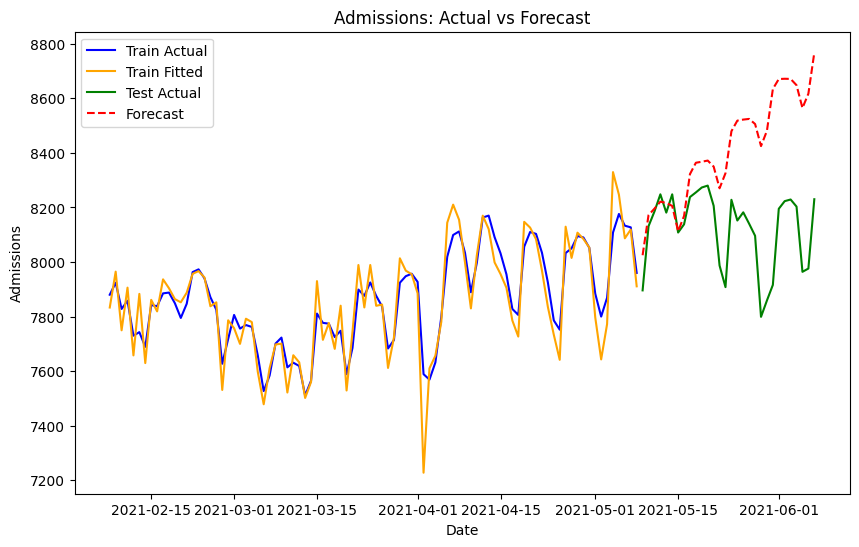

In [11]:
#| hide

# from feature_engine.encoding import OneHotEncoder, MeanEncoder, OrdinalEncoder, StringSimilarityEncoder, DecisionTreeEncoder
# ohe = OneHotEncoder(drop_last=True)
# mean_enc = MeanEncoder()
# ordinal_enc = OrdinalEncoder(encoding_method='ordered')
# string_sim_enc = StringSimilarityEncoder()
# decision_tree_enc = DecisionTreeEncoder(cv=3)

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
te = TargetEncoder(target_type="continuous")

from peshbeen.datasets import load_admission_calls
admission_calls = load_admission_calls()
## get day of week and month as features from the date index
admission_calls["day_of_week"] = admission_calls.index.dayofweek
admission_calls["month"] = admission_calls.index.month
train = admission_calls[:-30]
test = admission_calls[-30:]

cat_variables = ["day_of_week", "month"]

msvar_model = ms_var(
    n_components=3,
    target_cols=["admissions", "calls"],
    cat_variables=cat_variables,
    categorical_encoder=ohe,
    add_constant=True,
    lags={"admissions": 7, "calls": 7}, 
    difference={"admissions": 1, "calls": 1},
    change_points={'admissions': [100], "calls": [130]},
    method="posterior",
    n_iter=5,random_state=42)

msvar_model.fit(train)
msvar_model.predict_in_sample()  # generate in-sample predictions and residuals for diagnostics
forecasts = msvar_model.forecast(H=30, exog=test[cat_variables])

# plot actual vs forecasted for both targets
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train.index[-90:], train['admissions'][-90:], label='Train Actual', color='blue')
plt.plot(train.index[-90:], msvar_model.fitted_values["admissions"][-90:], label='Train Fitted', color='orange')
# plt.plot(train.index[-90:], msvar_model.in_samp_resids["admissions"][-90:], label='Train Fitted', color='orange')
plt.plot(test.index, test['admissions'], label='Test Actual', color='green')
plt.plot(test.index, forecasts['admissions'], label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.title('Admissions: Actual vs Forecast')
plt.legend()
plt.show()

In [12]:
#| hide

from peshbeen.metrics import WMAPE, MAE, RMSE
mtrcs = [WMAPE, MAE, RMSE]
cvdf = msvar_model.cross_validate(df=admission_calls, target_col='calls', cv_split=3, test_size=30, metrics=mtrcs)